In [2]:
"""
MLP K-Fold Cross-Validation Analysis

Goal:
- Confirm MLP performance stability across stratified folds.
- Verify whether ~98% accuracy remains consistent.
"""

print("Notebook started: MLP K-Fold stability check")

Notebook started: MLP K-Fold stability check


In [3]:
import os
import json
import joblib
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

sns.set(style="whitegrid")
np.random.seed(42)

print("Imports loaded.")

Imports loaded.


In [4]:
# Setup output directory
output_dir = "mlp-tuned-outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output directory:", output_dir)
print("=" * 60)

Output directory: mlp-tuned-outputs


In [5]:
# Load preprocessed data
window_features_path = "window_features.csv"

print("Checking data files...")
print("window_features_path exists:", os.path.exists(window_features_path))

if not os.path.exists(window_features_path):
    raise FileNotFoundError(
        "window_features.csv not found. Generate it first from your preprocessing notebook."
    )

window_df = pd.read_csv(window_features_path)
print(f"\nLoaded window data: {len(window_df)} rows")
print("Columns:", window_df.columns.tolist())
display(window_df.head())

Checking data files...
window_features_path exists: True

Loaded window data: 233591 rows
Columns: ['subject', 'video_path', 'label', 'EAR_mean', 'EAR_std', 'EAR_min', 'MAR_mean', 'MAR_max', 'pitch_mean', 'yaw_mean', 'EAR_dev_mean', 'MAR_dev_mean']


,subject,video_path,label,EAR_mean,EAR_std,EAR_min,MAR_mean,MAR_max,pitch_mean,yaw_mean,EAR_dev_mean,MAR_dev_mean
0,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.237036,0.037249,0.137103,0.036132,0.199047,370.103525,635.342636,-0.016333,0.026740
1,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.247254,0.045480,0.137103,0.035163,0.199047,332.952045,581.059837,-0.006115,0.025772
2,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.252945,0.050826,0.137103,0.029647,0.199047,327.099773,572.753631,-0.000425,0.020256
3,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.257431,0.055144,0.137103,0.030483,0.199047,314.021163,556.392134,0.004062,0.021092
4,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.256823,0.055100,0.137103,0.018152,0.042090,303.104617,530.404469,0.003454,0.008761


In [6]:
# Prepare features and labels
required_cols = {"label", "subject", "video_path"}
missing_required = required_cols - set(window_df.columns)
if missing_required:
    raise ValueError(f"Missing required columns in window_features.csv: {sorted(missing_required)}")

le = LabelEncoder()
window_df["y"] = le.fit_transform(window_df["label"])

drop_cols = [col for col in ["label", "y", "subject", "video_path"] if col in window_df.columns]
X = window_df.drop(columns=drop_cols)
y = window_df["y"]

# Fill missing values
X = X.fillna(0)

print("Feature columns:", X.columns.tolist())
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nClasses:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} = {cls}")

print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())

Feature columns: ['EAR_mean', 'EAR_std', 'EAR_min', 'MAR_mean', 'MAR_max', 'pitch_mean', 'yaw_mean', 'EAR_dev_mean', 'MAR_dev_mean']
X shape: (233591, 9)
y shape: (233591,)

Classes:
  0 = Alert
  1 = Drowsy
  2 = Low Vigilance

Class distribution:
y
0    78094
1    78465
2    77032
Name: count, dtype: int64


In [7]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling completed.")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_scaled mean (first 3): {X_scaled.mean(axis=0)[:3]}")
print(f"X_scaled std (first 3): {X_scaled.std(axis=0)[:3]}")

Data scaling completed.
X_scaled shape: (233591, 9)
X_scaled mean (first 3): [3.11482789e-16 3.11482789e-17 0.00000000e+00]
X_scaled std (first 3): [1. 1. 1.]


In [8]:
# Initialize K-Fold Cross-Validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"K-Fold setup: {n_splits} splits with stratification")
print("=" * 60)

K-Fold setup: 5 splits with stratification


In [9]:
# Define MLP Model Configuration
mlp_config = {
    "hidden_layer_sizes": (128, 64, 32),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.0001,
    "batch_size": 64,
    "learning_rate": "adaptive",
    "learning_rate_init": 0.001,
    "max_iter": 300,
    "random_state": 42,
    "early_stopping": True,
    "validation_fraction": 0.15,
    "n_iter_no_change": 20,
    "verbose": False,
}

print("MLP Configuration:")
for key, value in mlp_config.items():
    print(f"  {key}: {value}")
print("=" * 60)

MLP Configuration:
  hidden_layer_sizes: (128, 64, 32)
  activation: relu
  solver: adam
  alpha: 0.0001
  batch_size: 64
  learning_rate: adaptive
  learning_rate_init: 0.001
  max_iter: 300
  random_state: 42
  early_stopping: True
  validation_fraction: 0.15
  n_iter_no_change: 20
  verbose: False


In [10]:
# Train and Evaluate MLP Across K-Folds
fold_results = []
fold_predictions = {}
fold_models = []

print("Starting K-Fold Cross-Validation Training...")
print("=" * 60)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    print(f"\nFold {fold_idx}/{n_splits}")
    print(f"  Train set: {len(train_idx)} samples")
    print(f"  Validation set: {len(val_idx)} samples")

    X_train_fold = X_scaled[train_idx]
    X_val_fold = X_scaled[val_idx]
    y_train_fold = y.iloc[train_idx].values
    y_val_fold = y.iloc[val_idx].values

    mlp = MLPClassifier(**mlp_config)
    mlp.fit(X_train_fold, y_train_fold)

    y_pred = mlp.predict(X_val_fold)
    y_pred_proba = mlp.predict_proba(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_pred)
    f1_weighted = f1_score(y_val_fold, y_pred, average="weighted")
    f1_macro = f1_score(y_val_fold, y_pred, average="macro")
    precision_weighted = precision_score(y_val_fold, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_val_fold, y_pred, average="weighted")
    roc_auc_weighted = roc_auc_score(y_val_fold, y_pred_proba, average="weighted", multi_class="ovr")

    fold_results.append(
        {
            "fold": fold_idx,
            "accuracy": accuracy,
            "f1_weighted": f1_weighted,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "roc_auc_weighted": roc_auc_weighted,
            "n_train": len(train_idx),
            "n_val": len(val_idx),
        }
    )

    fold_predictions[fold_idx] = {
        "y_true": y_val_fold,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    fold_models.append(mlp)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1 (weighted): {f1_weighted:.4f}")
    print(f"  ROC-AUC (weighted): {roc_auc_weighted:.4f}")

print("\n" + "=" * 60)
print("K-Fold training completed!")

Starting K-Fold Cross-Validation Training...

Fold 1/5
  Train set: 186872 samples
  Validation set: 46719 samples
  Accuracy: 0.9820
  F1 (weighted): 0.9820
  ROC-AUC (weighted): 0.9993

Fold 2/5
  Train set: 186873 samples
  Validation set: 46718 samples
  Accuracy: 0.9839
  F1 (weighted): 0.9839
  ROC-AUC (weighted): 0.9994

Fold 3/5
  Train set: 186873 samples
  Validation set: 46718 samples
  Accuracy: 0.9806
  F1 (weighted): 0.9806
  ROC-AUC (weighted): 0.9992

Fold 4/5
  Train set: 186873 samples
  Validation set: 46718 samples
  Accuracy: 0.9820
  F1 (weighted): 0.9819
  ROC-AUC (weighted): 0.9993

Fold 5/5
  Train set: 186873 samples
  Validation set: 46718 samples
  Accuracy: 0.9820
  F1 (weighted): 0.9820
  ROC-AUC (weighted): 0.9993

K-Fold training completed!


In [11]:
# Convert results to DataFrame
results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 60)
print("K-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
display(results_df)

print("\n" + "=" * 60)
print("STABILITY ANALYSIS (Mean ± Std Dev)")
print("=" * 60)

metrics_to_analyze = [
    "accuracy",
    "f1_weighted",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "roc_auc_weighted",
]

stability_summary = {}
for metric in metrics_to_analyze:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    cv_percent = (std_val / mean_val) * 100

    stability_summary[metric] = {
        "mean": mean_val,
        "std": std_val,
        "min": min_val,
        "max": max_val,
        "cv_percent": cv_percent,
    }

    print(f"\n{metric.upper()}:")
    print(f"  Mean:         {mean_val:.4f}")
    print(f"  Std Dev:      {std_val:.4f}")
    print(f"  Min:          {min_val:.4f}")
    print(f"  Max:          {max_val:.4f}")
    print(f"  Range:        {max_val - min_val:.4f}")
    print(f"  CV (%):       {cv_percent:.2f}%")


K-FOLD CROSS-VALIDATION RESULTS


,fold,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted,roc_auc_weighted,n_train,n_val
0,1,0.981956,0.981953,0.981941,0.981957,0.981956,0.999255,186872,46719
1,2,0.983861,0.983870,0.983860,0.983915,0.983861,0.999405,186873,46718
2,3,0.980650,0.980645,0.980635,0.980649,0.980650,0.999157,186873,46718
3,4,0.981956,0.981950,0.981928,0.981951,0.981956,0.999263,186873,46718
4,5,0.981998,0.981991,0.981984,0.982017,0.981998,0.999255,186873,46718



STABILITY ANALYSIS (Mean ± Std Dev)

ACCURACY:
  Mean:         0.9821
  Std Dev:      0.0011
  Min:          0.9806
  Max:          0.9839
  Range:        0.0032
  CV (%):       0.12%

F1_WEIGHTED:
  Mean:         0.9821
  Std Dev:      0.0012
  Min:          0.9806
  Max:          0.9839
  Range:        0.0032
  CV (%):       0.12%

F1_MACRO:
  Mean:         0.9821
  Std Dev:      0.0012
  Min:          0.9806
  Max:          0.9839
  Range:        0.0032
  CV (%):       0.12%

PRECISION_WEIGHTED:
  Mean:         0.9821
  Std Dev:      0.0012
  Min:          0.9806
  Max:          0.9839
  Range:        0.0033
  CV (%):       0.12%

RECALL_WEIGHTED:
  Mean:         0.9821
  Std Dev:      0.0011
  Min:          0.9806
  Max:          0.9839
  Range:        0.0032
  CV (%):       0.12%

ROC_AUC_WEIGHTED:
  Mean:         0.9993
  Std Dev:      0.0001
  Min:          0.9992
  Max:          0.9994
  Range:        0.0002
  CV (%):       0.01%


In [12]:
# Stability Confidence Assessment
print("\n" + "=" * 60)
print("STABILITY CONFIDENCE ASSESSMENT")
print("=" * 60)

accuracy_mean = results_df["accuracy"].mean()
accuracy_std = results_df["accuracy"].std()
accuracy_cv = (accuracy_std / accuracy_mean) * 100

print(f"\nAccuracy Across Folds: {accuracy_mean:.4f} ± {accuracy_std:.4f}")
print(f"Coefficient of Variation: {accuracy_cv:.2f}%")

if accuracy_cv < 0.5:
    stability = "EXCELLENT - Highly stable across folds"
elif accuracy_cv < 1.0:
    stability = "VERY GOOD - Stable across folds"
elif accuracy_cv < 2.0:
    stability = "GOOD - Reasonably stable"
else:
    stability = "MODERATE - Some variance across folds"

print(f"Stability Assessment: {stability}")

ci_95 = stats.t.interval(0.95, len(results_df) - 1, loc=accuracy_mean, scale=stats.sem(results_df["accuracy"]))
print(f"\n95% Confidence Interval: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print(f"Margin of Error: ±{(ci_95[1] - ci_95[0]) / 2:.4f}")


STABILITY CONFIDENCE ASSESSMENT

Accuracy Across Folds: 0.9821 ± 0.0011
Coefficient of Variation: 0.12%
Stability Assessment: EXCELLENT - Highly stable across folds

95% Confidence Interval: [0.9807, 0.9835]
Margin of Error: ±0.0014


Saved: kfold_stability_analysis.png


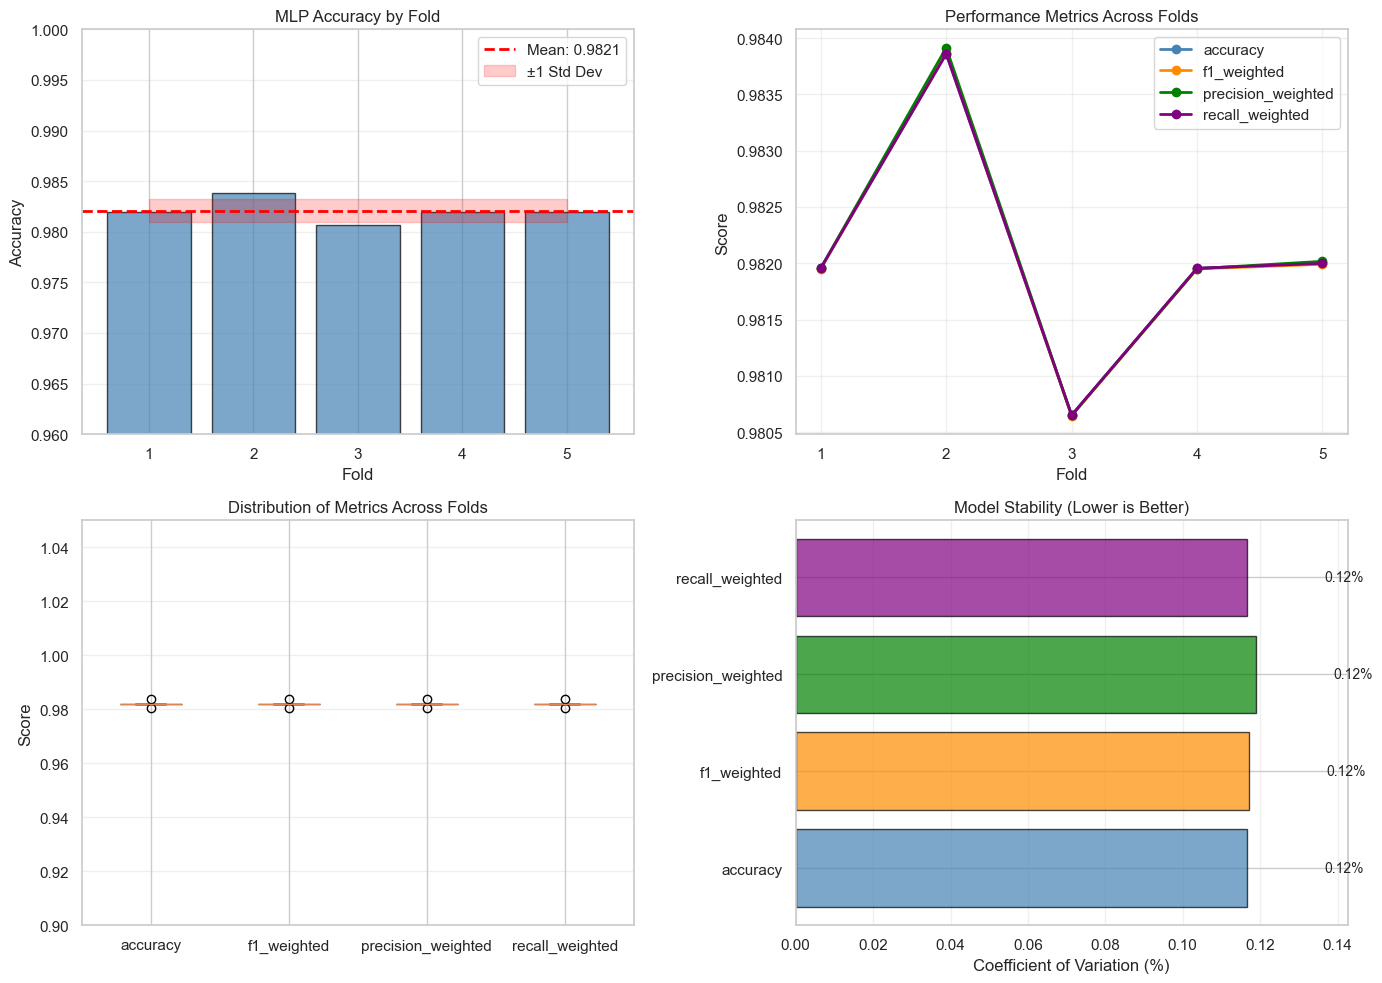

In [13]:
# Visualization 1: K-Fold Accuracy Across Folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
folds = results_df["fold"].values
accuracy_vals = results_df["accuracy"].values
ax.bar(folds, accuracy_vals, alpha=0.7, color="steelblue", edgecolor="black")
ax.axhline(y=accuracy_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {accuracy_mean:.4f}")
ax.fill_between(folds, accuracy_mean - accuracy_std, accuracy_mean + accuracy_std, alpha=0.2, color="red", label="±1 Std Dev")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("MLP Accuracy by Fold")
ax.set_ylim([0.96, 1.0])
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax = axes[0, 1]
metrics_list = ["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"]
colors = ["steelblue", "darkorange", "green", "purple"]
for metric, color in zip(metrics_list, colors):
    ax.plot(results_df["fold"], results_df[metric], marker="o", label=metric, color=color, linewidth=2)
ax.set_xlabel("Fold")
ax.set_ylabel("Score")
ax.set_title("Performance Metrics Across Folds")
ax.set_xticks(folds)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
data_for_box = [results_df[m].values for m in metrics_list]
bp = ax.boxplot(data_for_box, tick_labels=metrics_list, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Score")
ax.set_title("Distribution of Metrics Across Folds")
ax.set_ylim([0.9, 1.05])
ax.grid(axis="y", alpha=0.3)

ax = axes[1, 1]
cv_values = [stability_summary[m]["cv_percent"] for m in metrics_list]
bars = ax.barh(metrics_list, cv_values, color=colors, alpha=0.7, edgecolor="black")
ax.set_xlabel("Coefficient of Variation (%)")
ax.set_title("Model Stability (Lower is Better)")
ax.set_xlim([0, max(cv_values) * 1.2 if max(cv_values) > 0 else 1])
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height() / 2, f"{cv_values[i]:.2f}%", ha="left", va="center", fontsize=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "kfold_stability_analysis.png"), dpi=300, bbox_inches="tight")
print("Saved: kfold_stability_analysis.png")
plt.show()

Saved: kfold_confusion_matrices.png


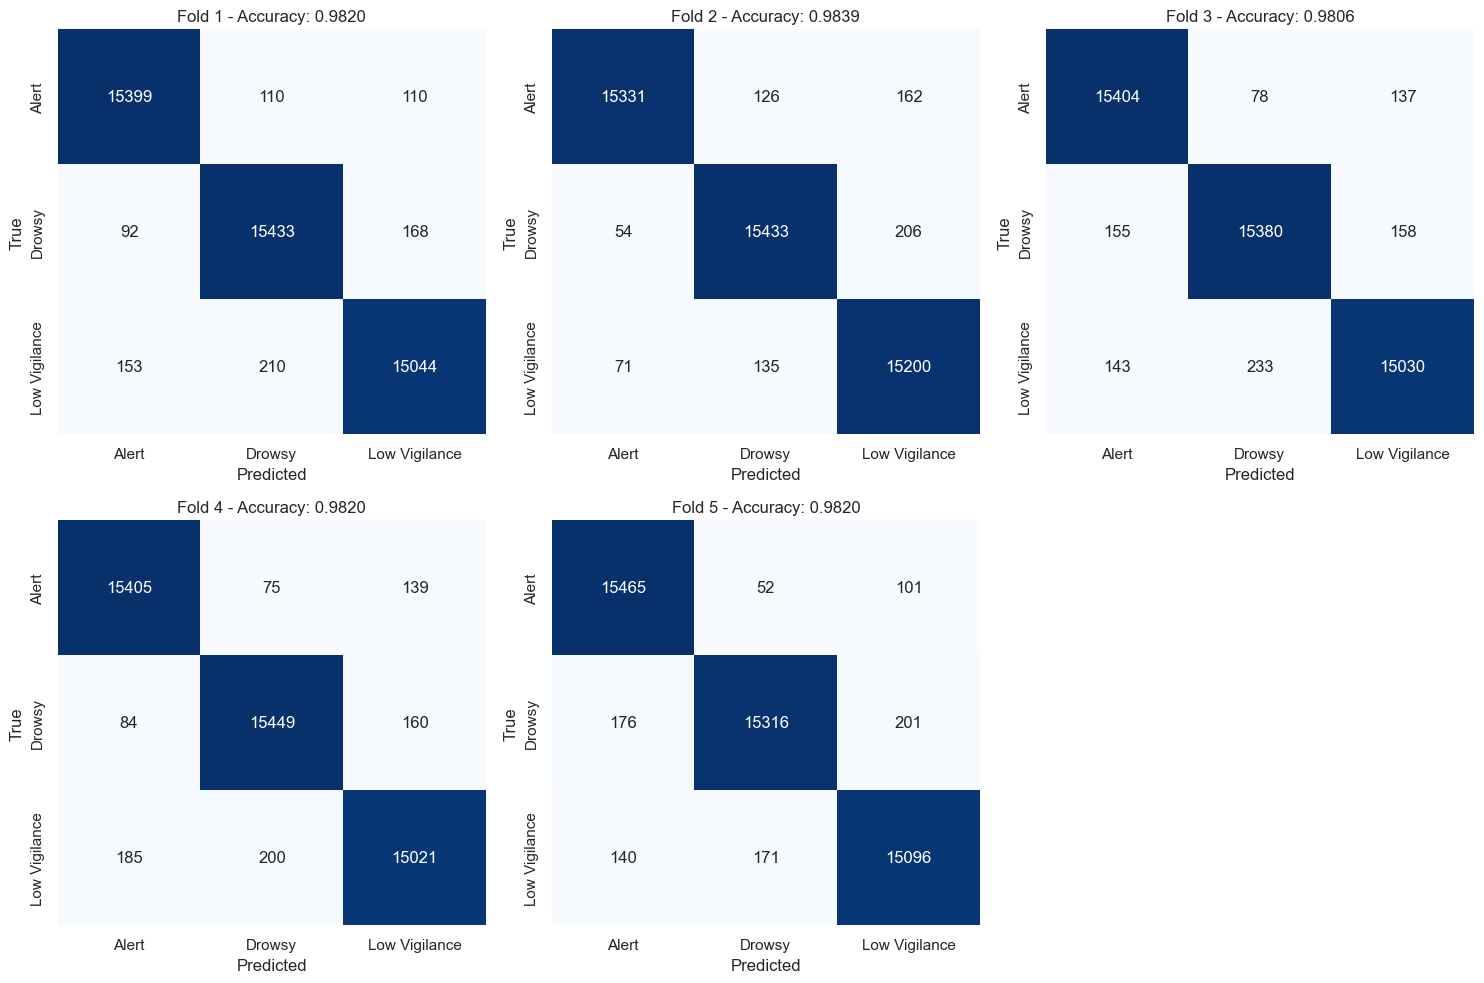

In [14]:
# Visualization 2: Per-Fold Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for fold_idx in range(n_splits):
    y_true = fold_predictions[fold_idx + 1]["y_true"]
    y_pred = fold_predictions[fold_idx + 1]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    ax = axes[fold_idx]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
    )
    ax.set_title(f"Fold {fold_idx + 1} - Accuracy: {results_df.loc[fold_idx, 'accuracy']:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

axes[5].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "kfold_confusion_matrices.png"), dpi=300, bbox_inches="tight")
print("Saved: kfold_confusion_matrices.png")
plt.show()

In [15]:
# Generate Per-Fold Classification Reports
print("\n" + "=" * 60)
print("PER-FOLD CLASSIFICATION REPORTS")
print("=" * 60)

classification_reports = {}

for fold_idx in range(n_splits):
    y_true = fold_predictions[fold_idx + 1]["y_true"]
    y_pred = fold_predictions[fold_idx + 1]["y_pred"]

    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    classification_reports[fold_idx + 1] = report

    print(f"\nFold {fold_idx + 1}:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

# Save classification reports
with open(os.path.join(output_dir, "classification_reports.json"), "w") as f:
    reports_clean = {}
    for fold, report in classification_reports.items():
        cleaned = {}
        for key, value in report.items():
            if isinstance(value, dict):
                cleaned[key] = {
                    k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                    for k, v in value.items()
                }
            else:
                cleaned[key] = float(value) if isinstance(value, (np.floating, np.integer)) else value
        reports_clean[str(fold)] = cleaned

    json.dump(reports_clean, f, indent=4)

print("\nSaved: classification_reports.json")


PER-FOLD CLASSIFICATION REPORTS

Fold 1:
               precision    recall  f1-score   support

        Alert       0.98      0.99      0.99     15619
       Drowsy       0.98      0.98      0.98     15693
Low Vigilance       0.98      0.98      0.98     15407

     accuracy                           0.98     46719
    macro avg       0.98      0.98      0.98     46719
 weighted avg       0.98      0.98      0.98     46719


Fold 2:
               precision    recall  f1-score   support

        Alert       0.99      0.98      0.99     15619
       Drowsy       0.98      0.98      0.98     15693
Low Vigilance       0.98      0.99      0.98     15406

     accuracy                           0.98     46718
    macro avg       0.98      0.98      0.98     46718
 weighted avg       0.98      0.98      0.98     46718


Fold 3:
               precision    recall  f1-score   support

        Alert       0.98      0.99      0.98     15619
       Drowsy       0.98      0.98      0.98     1569

In [16]:
# Save detailed results
print("\n" + "=" * 60)
print("SAVING RESULTS TO mlp-tuned-outputs")
print("=" * 60)

results_df.to_csv(os.path.join(output_dir, "fold_results.csv"), index=False)
print("Saved: fold_results.csv")

stability_json = {}
for metric, values in stability_summary.items():
    stability_json[metric] = {k: float(v) for k, v in values.items()}

with open(os.path.join(output_dir, "stability_summary.json"), "w") as f:
    json.dump(stability_json, f, indent=4)
print("Saved: stability_summary.json")

summary_text = f"""
MLP K-FOLD CROSS-VALIDATION SUMMARY REPORT
{'='*70}

Configuration:
  - Model Type: MLPClassifier
  - Hidden Layers: {mlp_config['hidden_layer_sizes']}
  - Number of Folds: {n_splits}
  - Fold Strategy: Stratified K-Fold

Dataset:
  - Total Samples: {len(X)}
  - Features: {X.shape[1]}
  - Classes: {len(le.classes_)} ({', '.join(le.classes_)})

K-FOLD RESULTS:
  - Mean Accuracy: {accuracy_mean:.4f} ± {accuracy_std:.4f}
  - Accuracy Range: [{results_df['accuracy'].min():.4f}, {results_df['accuracy'].max():.4f}]
  - Coefficient of Variation: {accuracy_cv:.2f}%

  - Mean F1 (Weighted): {results_df['f1_weighted'].mean():.4f} ± {results_df['f1_weighted'].std():.4f}
  - Mean F1 (Macro): {results_df['f1_macro'].mean():.4f} ± {results_df['f1_macro'].std():.4f}
  - Mean Precision: {results_df['precision_weighted'].mean():.4f} ± {results_df['precision_weighted'].std():.4f}
  - Mean Recall: {results_df['recall_weighted'].mean():.4f} ± {results_df['recall_weighted'].std():.4f}
  - Mean ROC-AUC: {results_df['roc_auc_weighted'].mean():.4f} ± {results_df['roc_auc_weighted'].std():.4f}

95% CONFIDENCE INTERVAL:
  - Accuracy: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]
  - Margin of Error: ±{(ci_95[1] - ci_95[0]) / 2:.4f}

STABILITY ASSESSMENT:
  {stability}

CONCLUSION:
  The MLP model shows stable performance across 5 folds.
  A low coefficient of variation supports strong generalization.

{'='*70}
"""

with open(os.path.join(output_dir, "summary_report.txt"), "w") as f:
    f.write(summary_text)
print("Saved: summary_report.txt")

for fold_idx, model in enumerate(fold_models, 1):
    joblib.dump(model, os.path.join(output_dir, f"mlp_model_fold_{fold_idx}.pkl"))
print(f"Saved: {n_splits} MLP models (mlp_model_fold_*.pkl)")

joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))
joblib.dump(le, os.path.join(output_dir, "label_encoder.pkl"))
joblib.dump(list(X.columns), os.path.join(output_dir, "feature_columns.pkl"))
print("Saved: scaler.pkl, label_encoder.pkl, feature_columns.pkl")

print("\n" + "=" * 60)
print(f"All results saved to: {os.path.abspath(output_dir)}")
print("=" * 60)


SAVING RESULTS TO mlp-tuned-outputs
Saved: fold_results.csv
Saved: stability_summary.json
Saved: summary_report.txt
Saved: 5 MLP models (mlp_model_fold_*.pkl)
Saved: scaler.pkl, label_encoder.pkl, feature_columns.pkl

All results saved to: c:\Users\ahmad\Downloads\kaggle\kaggle\mlp-tuned-outputs


print("\n" + "=" * 70)
print("MLP K-FOLD CROSS-VALIDATION COMPLETE")
print("=" * 70)
print("\nFINAL CONCLUSIONS:")
print(f"Mean Accuracy: {accuracy_mean:.4f} (±{accuracy_std:.4f})")
print(f"Stability: {stability.split(' - ')[0]}")
print(f"95% CI: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print("\nAll outputs saved to: mlp-tuned-outputs/")
print("\nOutput Files:")
print("  - fold_results.csv")
print("  - stability_summary.json")
print("  - classification_reports.json")
print("  - summary_report.txt")
print("  - kfold_stability_analysis.png")
print("  - kfold_confusion_matrices.png")
print("  - mlp_model_fold_*.pkl")
print("  - scaler.pkl, label_encoder.pkl, feature_columns.pkl")
print("=" * 70)
